<a href="https://colab.research.google.com/github/vivek-kothekar/ML-Lab-Practicals/blob/main/Practical_10_Vivek_Kothekar_(CS23110).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Vivek R. Kothekar   (CS23110)**

**AIM :** To perform hierarchical clustering using agglomerative methods and interpret dendrograms for cluster formation.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
path= '/content/drive/MyDrive/ML/P_9.csv'
df=pd.read_csv(path)
df.head(5)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
X = df[['Annual Income (k$)','Spending Score (1-100)']]

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

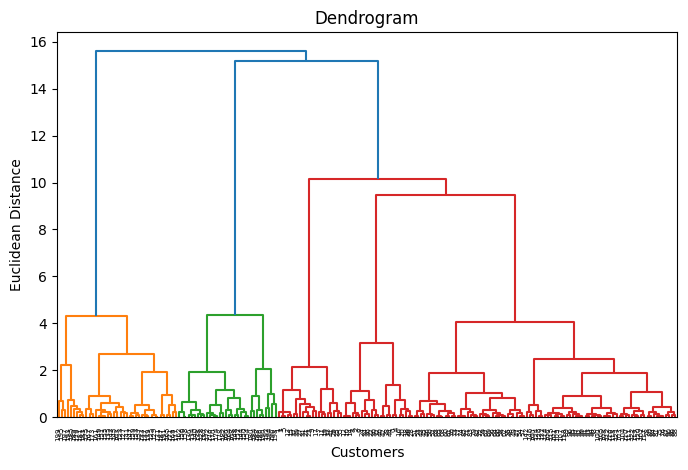

In [6]:
from scipy.cluster.hierarchy import dendrogram, linkage # Re-import dendrogram to ensure it refers to the function
plt.figure(figsize=(8, 5))
dendrogram(linkage(X_scaled, method='ward'))
plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")
plt.show()

In [7]:
hc = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
clusters = hc.fit_predict(X_scaled)

In [8]:
df['cluster']=clusters
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   cluster  
0        4  
1        3  
2        4  
3        3  
4        4  


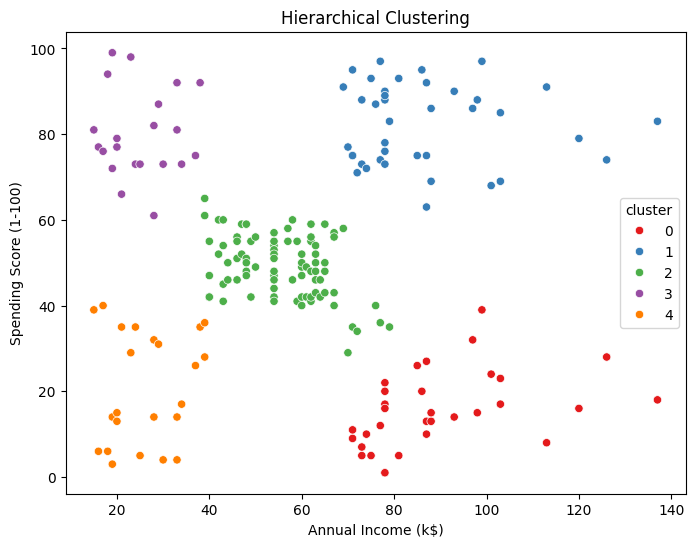

In [9]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='cluster',
    data=df,
    palette='Set1'
)
plt.title('Hierarchical Clustering')
plt.show()